# Оценка экономического эффекта модели

В этом проекте мы будем работать с данными [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). Этот датасет содержит информацию о банковском телефонном маркетинге.

__Объектом__ здесь является телефонный звонок потенциальному клиенту с предложением некоторой услуги (утверждается, что это краткосрочный депозит). В качестве признакового описания используются характеристики клиента (образование, брак и т.д.), данные о звонке и различные экономические индикаторы - более подробная информация представлена в файле `bank-additional-names.txt`.
__Целевая переменная__ - ответ клиента (согласился ли он открыть депозит?)

## Подготовка

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

Скачаем данные

In [2]:
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

In [3]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
30129,24,technician,single,university.degree,no,yes,no,cellular,apr,thu,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.365,5099.1,no
15470,45,blue-collar,divorced,basic.4y,unknown,yes,no,cellular,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,no
24282,42,technician,married,professional.course,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
21041,47,technician,married,university.degree,no,yes,no,cellular,aug,thu,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
31125,34,admin.,single,university.degree,no,yes,no,cellular,may,wed,...,1,999,1,failure,-1.8,92.893,-46.2,1.334,5099.1,no


Определим выборку

In [4]:
X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes') + 0

## Пайплайн

Будем использовать кросс-валидацию.  Используем 5 фолдов, `shuffle`=True

In [5]:
categorical = X.select_dtypes("object")
numeric = X.select_dtypes("number")

In [6]:
y.mean()

np.float64(0.11265417111780131)

Баланс классов нарушен, используем стратифицированный отбор

In [7]:
from sklearn.model_selection import StratifiedKFold

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True
)

Создадим пайплайн для обучения (воспользуемся `OneHotEncoder` для категориальных признаков и `StandardScaler` для числовых, гиперпараметры по умолчанию)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [10]:
transformer = ColumnTransformer(
    [("ohe", OneHotEncoder(handle_unknown="ignore"), categorical.columns),
     ("scale", StandardScaler(), numeric.columns)]
)

In [11]:
lr = Pipeline(
    [("transform", transformer),
     ("lr", LogisticRegression())]
)

## Математическая модель задачи

Допустим, работники вашего колл-центра получают за один звонок клиенту 1 доллар. При согласии клиента на предлагаемые условия он принесет в банк от 10 до 20 долларов.  
Предположим, что всем положительным прогнозам наши сотрудники решили позвонить. Посчитаем прибыль по кросс-валидации

In [12]:
from sklearn.metrics import make_scorer

In [13]:
def count_profit(y_true, y_pred):
    rng = np.random.default_rng()
    profit = np.where(
        (y_pred == 1) & (y_true == 1), rng.uniform(10, 20),   # TP
        np.where(
            (y_pred == 1) & (y_true == 0), -1,  # FP
            0
        )
    )
    return profit

In [14]:
def mean_profit_score(y_true, y_pred):
    return count_profit(y_true, y_pred).mean()

mean_profit_scorer = make_scorer(
    mean_profit_score,
    response_method="predict"
)

In [15]:
from sklearn.model_selection import cross_val_score

In [16]:
cv_scores = cross_val_score(
    lr, 
    X, y,
    scoring=mean_profit_scorer,
    cv=cv,
    n_jobs=-1
)
print(f"Прибыль в среднем за одного клиента: {np.mean(cv_scores)} долларов")

Прибыль в среднем за одного клиента: 0.36247412175875465 долларов


Настроим по кросс-валидации коэффициент регуляризации модели для максимизации прибыли

In [17]:
from sklearn.model_selection import GridSearchCV

In [18]:
gs = GridSearchCV(
    lr,
    {"lr__C": np.logspace(-3, 3, 10)},
    scoring=mean_profit_scorer,
    n_jobs=-1,
    cv=cv
)

In [19]:
gs.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'lr__C': array([1.0000...00000000e+03])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

Посмотрим, как менялась прибыль для разных коэффициентов регуляризации. Отобразим также стандартное отклонение

In [20]:
c = gs.param_grid["lr__C"]
mean_scores = gs.cv_results_["mean_test_score"]
std_scores = gs.cv_results_["std_test_score"]

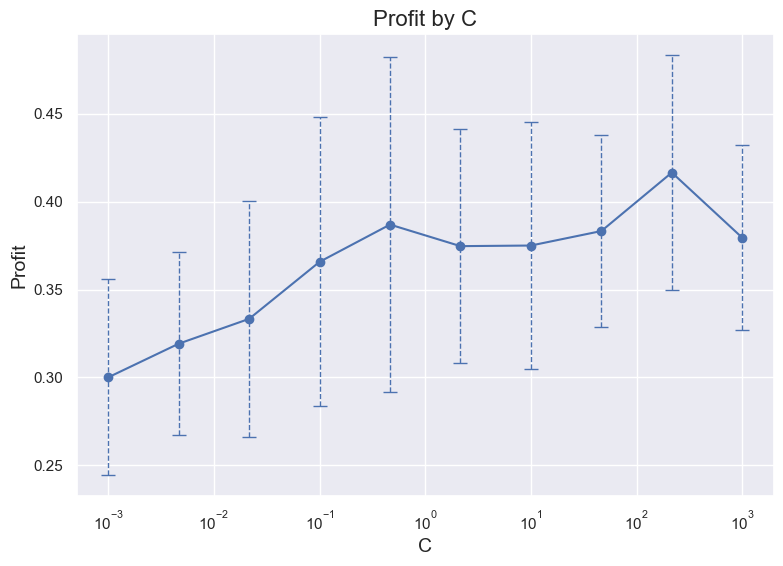

In [21]:
plt.figure(figsize=(9, 6))

line, caplines, barlinecols = plt.errorbar(
    x=c,
    y=mean_scores,
    yerr=std_scores,
    ls="-",
    fmt="o",
    elinewidth=1,
    capsize=5
)

for bar in barlinecols:
    bar.set_linestyle('--')

plt.title("Profit by C", fontsize=16)
plt.xlabel("C", fontsize=14)
plt.ylabel("Profit", fontsize=14)
plt.xscale("log")

plt.show()

Видно, что для разных коэффициентов C, метрика прибыли изменяется не больше, чем на стандартное отклонение

Попробуем повторить эксперимент несколько раз. Посмотрим на динамику подобранных коэффициентов

In [22]:
best_c_with_scores = []
for _ in range(10):
    gs.fit(X, y)
    c = gs.best_params_["lr__C"]
    profit = gs.best_score_
    best_c_with_scores.append((c, profit))
best_c_with_scores

[(np.float64(0.021544346900318832), np.float64(0.4111598946211285)),
 (np.float64(0.46415888336127775), np.float64(0.3764376433389283)),
 (np.float64(46.41588833612773), np.float64(0.4344582704343619)),
 (np.float64(1000.0), np.float64(0.42248568476576887)),
 (np.float64(1000.0), np.float64(0.4190074055135716)),
 (np.float64(1000.0), np.float64(0.4250792345740629)),
 (np.float64(0.46415888336127775), np.float64(0.40401394272363556)),
 (np.float64(215.44346900318823), np.float64(0.40090323700174746)),
 (np.float64(0.1), np.float64(0.41277432852626966)),
 (np.float64(215.44346900318823), np.float64(0.40487437888757566))]

Коэффициенты регуляризации постоянно разные, однако целевая метрика примерно одинаковая. Поэтому будем использовать C, который покажется нам лучше

## Ключевая метрика

Проверим, что для бизнеса важнее — хороший precision или recall модели?

Настроим порог бинаризации на кросс-валидации для максимизации прибыли.  
Для этого воспользуемся сеткой от 0 до 1 с шагом 0.01

In [23]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone

class ThresholdClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator
        self.threshold = threshold

    def fit(self, X, y):
        self.classes_ = np.unique(y)        
        return self

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)

In [24]:
classifier = ThresholdClassifier(LogisticRegression(C=46))

model = Pipeline(
    [("transform", transformer),
     ("classify", classifier)]
)

In [25]:
thresh_grid = np.arange(0, 101) / 100

gs = GridSearchCV(
    model,
    {"classify__threshold": thresh_grid},
    scoring=mean_profit_scorer,
    cv=cv,
    n_jobs=-1,
    error_score="raise"
)

gs.fit(X, y)
print(f"Best threshold: {gs.best_params_["classify__threshold"]}")

Best threshold: 0.09


In [26]:
model = gs.best_estimator_

Построим график зависимости прибыли от порога бинаризации, также отметим на нем стандартные отклонения

In [27]:
mean_scores = np.array(gs.cv_results_["mean_test_score"])
std_scores = np.array(gs.cv_results_["std_test_score"])

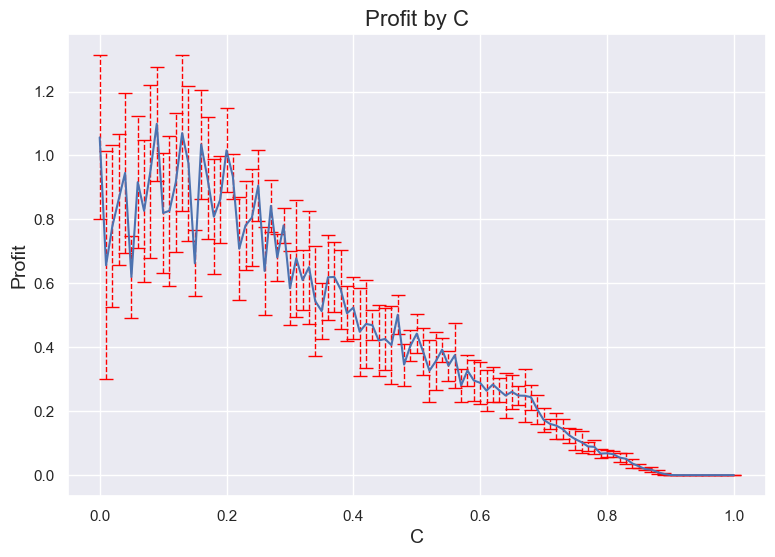

In [28]:
plt.figure(figsize=(9, 6))

line, caplines, barlinecols = plt.errorbar(
    x=thresh_grid,
    y=mean_scores,
    yerr=std_scores,
    ecolor="red",
    elinewidth=1,
    capsize=5
)

for bar in barlinecols:
    bar.set_linestyle('--')

plt.title("Profit by C", fontsize=16)
plt.xlabel("C", fontsize=14)
plt.ylabel("Profit", fontsize=14)

plt.show()

Пороги с наибольшей прибылью < 0.5. Из этого следует, что в этой задаче для бизнеса важнее recall, нежели precision

Попробуем подобрать порог еще несколько раз, чтобы убедиться

In [29]:
thresholds = []
for _ in range(10):
    gs.fit(X, y)
    thresholds.append(gs.best_params_["classify__threshold"])
thresholds

[np.float64(0.07),
 np.float64(0.04),
 np.float64(0.09),
 np.float64(0.07),
 np.float64(0.08),
 np.float64(0.09),
 np.float64(0.08),
 np.float64(0.03),
 np.float64(0.09),
 np.float64(0.05)]

Предположение подтвердилось

## Метрика качества модели

Оценим по кросс-валидации значения precision и recall

In [30]:
mean_scores = {}
std_scores = {}
for scoring in ["precision", "recall"]:
    cv_score = cross_val_score(
        model,
        X, y,
        scoring=scoring,
        cv=cv,
        n_jobs=-1
    )
    mean_scores[scoring] = np.mean(cv_score)
    std_scores[scoring] = np.std(cv_score)
print(f"Mean:\t {mean_scores}")
print(f"STD:\t {std_scores}")

Mean:	 {'precision': np.float64(0.29478069581310884), 'recall': np.float64(0.678448275862069)}
STD:	 {'precision': np.float64(0.003922161237442761), 'recall': np.float64(0.017168488160908983)}


Можно пронаблюдать, что наша модель склоняется к более высокому recall. Попробуем оценить качество модели с помощью `PR-AUC` в зоне recall $\geq$ 0.5. Сделаем это следующим образом:
- выберем только те пороги, на которых достигается необходимый recall,
- затем интерпретируем отсеченный в единичном квадрате прямоугольник как новый единичный квадрат,
- посчитаем площадь под отсеченной кривой

In [31]:
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import minmax_scale

In [32]:
def thresh_pr_auc_score(y_true, y_prob):
    pr, rec, _ = precision_recall_curve(y_true, y_prob)
    mask = rec >= 0.5
    pr = minmax_scale(pr[mask])
    rec = minmax_scale(rec[mask])
    return auc(rec, pr)

In [33]:
thresh_pr_auc_scorer = make_scorer(
    thresh_pr_auc_score,
    response_method="predict_proba"
)

In [34]:
cv_score = cross_val_score(
    model,
    X, y,
    scoring=thresh_pr_auc_scorer,
    cv=cv,
    n_jobs=-1
)

In [35]:
print(f"PR-AUC: {np.mean(cv_score)}")

PR-AUC: 0.4108411823447159
